<a href="https://colab.research.google.com/github/seigdev/artificial-intelligence/blob/main/assessments/assignment_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
%pip install nltk

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import requests
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import gensim
import re
import nltk
import tldextract
import seaborn as sns
from urllib.parse import urlparse
from Levenshtein import distance as levenshtein_distance
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras import losses

/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2025-04-05 22:37:44.359931: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


No supported GPU was found.


## data collection

In [2]:
datasets_raw = "https://raw.githubusercontent.com/seigdev/resources/refs/heads/main/crypto_data.json"
datasets_df = pd.read_json(datasets_raw)

## eda

In [3]:
# view the first few rows
datasets_df.head()

,url,label,label_no
0,https://arbitrum-claim.net,scam,1
1,https://allocate-dym.network,scam,1
2,https://espacejeux.com,legit,0
3,https://net-layerzero.com,scam,1
4,https://leugss.top,scam,1


In [4]:
# basic info
print(datasets_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       100000 non-null  object
 1   label     100000 non-null  object
 2   label_no  100000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.3+ MB
None


In [5]:
# count the number of scam and legitimate links
datasets_df["label"].value_counts()

label
scam     80000
legit    20000
Name: count, dtype: int64

In [6]:
# Summary statistics for numerical columns (if any)
datasets_df.describe()

,label_no
count,100000.000000
mean,0.800000
std,0.400002
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


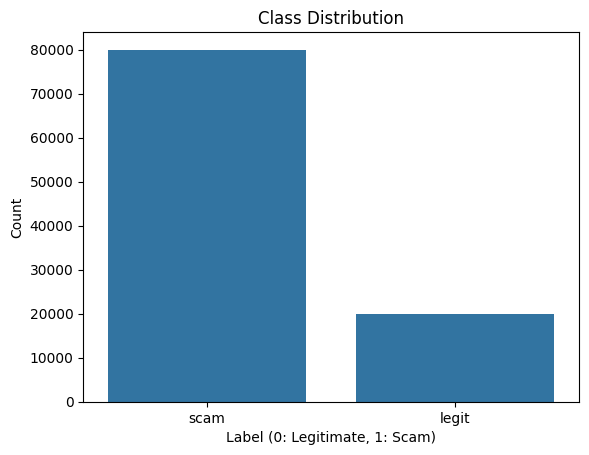

In [7]:
#  count the number of scam and legitimate links
class_distribution = datasets_df["label"].value_counts()

# plot the distribution
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title("Class Distribution")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Count")
plt.show()

Unique domains: 65185
Top TLDs: tld
com       34126
io        10689
xyz        5337
net        5155
app        4702
org        4337
dev        3922
top        1845
online     1564
site       1511
Name: count, dtype: int64


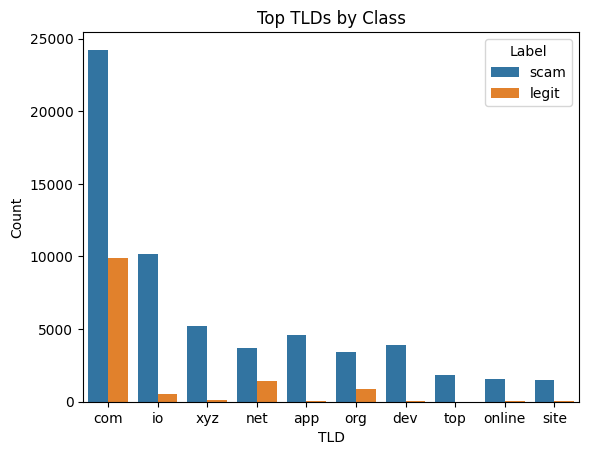

In [8]:
# extract domain and TLD
datasets_df["domain"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).domain)
datasets_df["tld"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).suffix)

# count unique domains and TLDs
print("Unique domains:", datasets_df["domain"].nunique())
print("Top TLDs:", datasets_df["tld"].value_counts().head(10))

# compare TLDs for scam vs. legitimate links
sns.countplot(x="tld", hue="label", data=datasets_df, order=datasets_df["tld"].value_counts().iloc[:10].index)
plt.title("Top TLDs by Class")
plt.xlabel("TLD")
plt.ylabel("Count")
plt.legend(title="Label", loc="upper right")
plt.show()

In [9]:
# drop label column since it contains text representation
# and we will use label_no for numerical representation
datasets_df.drop(columns=["label"], inplace=True)

# rename label_no to label for consistency
datasets_df.rename(columns={"label_no": "label"}, inplace=True)

## preprocessing

In [10]:
def clean_url(url):
    url = re.sub(r'https?://(www\.)?', '', url.lower())

    url = re.sub(r'\.[a-z]{2,3}(?=\/|$)', '', url)

    tokens = re.split(r'[/?=&.-]', url)
    tokens = [token for token in tokens if token] 
    
    return " ".join(tokens)

# Apply cleaning to DataFrame
datasets_df['cleaned_url'] = datasets_df['url'].apply(clean_url)

In [11]:
# Feature Extraction Function
def extract_features(url):
    features = {}
    features['url_length'] = len(url)
    features['num_digits'] = sum(c.isdigit() for c in url)
    features['num_special_chars'] = len(re.findall(r'[^a-zA-Z0-9]', url))
    features['num_subdomains'] = url.count('.')
    features['has_https'] = 1 if 'https' in url else 0
    features['suspicious_keywords'] = sum(kw in url for kw in ["free", "bonus", "earn", "crypto", "win"])
    return features

# Apply feature extraction
df_features = datasets_df['url'].apply(lambda x: pd.Series(extract_features(x)))

In [12]:
datasets_df

,url,label,domain,tld,cleaned_url
0,https://arbitrum-claim.net,1,arbitrum-claim,net,arbitrum claim
1,https://allocate-dym.network,1,allocate-dym,network,allocate dym network
2,https://espacejeux.com,0,espacejeux,com,espacejeux
3,https://net-layerzero.com,1,net-layerzero,com,net layerzero
4,https://leugss.top,1,leugss,top,leugss
...,...,...,...,...,...
99995,https://hdfcbank.com,0,hdfcbank,com,hdfcbank
99996,https://saintssinnersnft.com,1,saintssinnersnft,com,saintssinnersnft
99997,https://convexfinence.com,1,convexfinence,com,convexfinence
99998,https://kyberswap.com/swap?r=coingecko,0,kyberswap,com,kyberswap swap r coingecko


## feature engineering

In [13]:
# function to detect typosquatting
def detect_typosquatting(url, legitimate_domains, threshold=2):
    parsed_url = urlparse(url)
    domain = parsed_url.netloc.lower()

    for legit_domain in legitimate_domains:
        if levenshtein_distance(domain, legit_domain) <= threshold:
            return 1
    return 0

In [14]:
# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(datasets_df['cleaned_url'], datasets_df['label'], test_size=0.2, random_state=42)
X_train_features, X_test_features = train_test_split(df_features, test_size=0.2, random_state=42)

In [15]:
map = {0: "legit", 1: "scam"}
map

{0: 'legit', 1: 'scam'}

#### word2Vec

In [16]:
# Train custom Word2Vec model
sentences = [word_tokenize(url) for url in datasets_df['cleaned_url'].tolist()]

# Initialize and build vocabulary in one step
word2vec_model = gensim.models.Word2Vec(
    sentences=sentences,  # This builds the vocabulary automatically
    vector_size=300,
    window=5,
    min_count=1,
    workers=4
)

# # Now train the model
word2vec_model.train(
    sentences,
    total_examples=word2vec_model.corpus_count,
    epochs=10
)

# # Save the trained model
word2vec_model.save("word2vec_model.bin")

In [17]:
# Build embedding matrix from trained Word2Vec
embedding_matrix = np.zeros((len(word2vec_model.wv) + 1, 300))
for i, word in enumerate(word2vec_model.wv.index_to_key):
    embedding_matrix[i] = word2vec_model.wv[word]

#### TF-IDF

In [18]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Combine lexical and TF-IDF features
X_train_combined = np.hstack((X_train_tfidf.toarray(), X_train_features.to_numpy()))
X_test_combined = np.hstack((X_test_tfidf.toarray(), X_test_features.to_numpy()))

#### nnlm-50

In [19]:
# load NNLM embeddings (50-dimensional)
embed_50 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_50 = embed_50(datasets_df["cleaned_url"].tolist()).numpy()

X_embeddings_50

2025-04-05 22:40:16.761625: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'sentences' with dtype string and shape [?]
	 [[{{node sentences}}]]


array([[ 0.03077845, -0.26711562,  0.01830282, ...,  0.2072107 ,
         0.02002396,  0.11362913],
       [ 0.12560877, -0.11177091, -0.02211482, ...,  0.00737813,
         0.40654805,  0.32076135],
       [ 0.10182011,  0.06991228, -0.12868926, ...,  0.08619068,
         0.02749146,  0.0405954 ],
       ...,
       [ 0.42437407,  0.17515412,  0.0380774 , ...,  0.06362747,
        -0.03616028,  0.16073953],
       [ 0.11032847, -0.0125842 ,  0.067099  , ...,  0.03323994,
         0.05068972,  0.00511996],
       [ 0.35567272,  0.02948582, -0.23257488, ...,  0.08631268,
         0.28958815,  0.0254384 ]], dtype=float32)

#### nnlm-128

In [20]:
# using nnlm-128

# load NNLM embeddings (128-dimensional)
embed_128 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_128 = embed_128(datasets_df["cleaned_url"].tolist()).numpy()

X_embeddings_128

2025-04-05 22:40:17.539152: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'sentences' with dtype string and shape [?]
	 [[{{node sentences}}]]


array([[ 0.03077845, -0.26711562,  0.01830282, ...,  0.2072107 ,
         0.02002396,  0.11362913],
       [ 0.12560877, -0.11177091, -0.02211482, ...,  0.00737813,
         0.40654805,  0.32076135],
       [ 0.10182011,  0.06991228, -0.12868926, ...,  0.08619068,
         0.02749146,  0.0405954 ],
       ...,
       [ 0.42437407,  0.17515412,  0.0380774 , ...,  0.06362747,
        -0.03616028,  0.16073953],
       [ 0.11032847, -0.0125842 ,  0.067099  , ...,  0.03323994,
         0.05068972,  0.00511996],
       [ 0.35567272,  0.02948582, -0.23257488, ...,  0.08631268,
         0.28958815,  0.0254384 ]], dtype=float32)

## modelling

#### logistics regression

/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8516
              precision    recall  f1-score   support

           0       0.67      0.49      0.57      3943
           1       0.88      0.94      0.91     16057

    accuracy                           0.85     20000
   macro avg       0.78      0.72      0.74     20000
weighted avg       0.84      0.85      0.84     20000



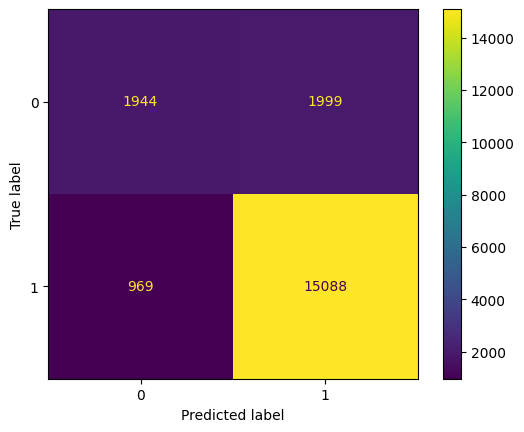

In [21]:
lr = LogisticRegression()
lr.fit(X_train_combined, y_train)
lr_preds = lr.predict(X_test_combined)
confusion = confusion_matrix(y_test, lr_preds)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))  
disp = ConfusionMatrixDisplay(confusion, display_labels = map.keys())
disp.plot()
plt.show()

In [22]:
# Tokenizing for NN models
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

# Rebuild embedding matrix to match Tokenizer's vocabulary
vocab_size = embedding_matrix.shape[0]
embedding_matrix = np.zeros((vocab_size, 300))

for word, i in tokenizer.word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]

# Then use as before
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=50)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=50)

print("X_train_seq type:", type(X_train_seq[0][0]))  # Should be int/float
print("y_train type:", type(y_train[0])) 

X_train_seq type: <class 'numpy.int32'>
y_train type: <class 'numpy.int64'>


#### LSTM

In [23]:
# Example: Focal Loss (for class imbalance)
def focal_loss(y_true, y_pred, alpha=0.25, gamma=2):
    # Custom implementation
    return losses.binary_crossentropy(y_true, y_pred) * alpha * (1 - y_pred)**gamma

# Build LSTM model
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=300, weights=[embedding_matrix], input_length=50, trainable=True),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss=focal_loss, metrics=['accuracy'])
lstm_model.fit(X_train_seq, y_train, epochs=5, validation_data=(X_test_seq, y_test))

2025-04-05 22:41:17.089579: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-05 22:41:17.091485: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-05 22:41:17.093541: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Epoch 1/5


2025-04-05 22:41:18.154881: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-05 22:41:18.157652: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-05 22:41:18.160328: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

 104/2500 [>.............................] - ETA: 21:21 - loss: 0.0025 - accuracy: 0.7939

KeyboardInterrupt: 

#### CNN

In [ ]:
# Build CNN model
cnn_model = Sequential([
    Embedding(input_dim=len(word2vec_model.wv) + 1, output_dim=300, weights=[embedding_matrix], input_length=50, trainable=True),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_seq, y_train, epochs=5, validation_data=(X_test_seq, y_test))

Epoch 1/5
2500/2500 [==============================] - 9139s 4s/step - loss: 0.3186 - accuracy: 0.8262 - val_loss: 0.3062 - val_accuracy: 0.7975
Epoch 2/5
2500/2500 [==============================] - 2825s 1s/step - loss: 0.0284 - accuracy: 0.9917 - val_loss: 0.4967 - val_accuracy: 0.7893
Epoch 3/5
2500/2500 [==============================] - 8832s 4s/step - loss: 0.0132 - accuracy: 0.9956 - val_loss: 0.5967 - val_accuracy: 0.7844
Epoch 4/5
2500/2500 [==============================] - 2020s 808ms/step - loss: 0.0096 - accuracy: 0.9966 - val_loss: 0.5931 - val_accuracy: 0.7691
Epoch 5/5
2500/2500 [==============================] - 4543s 2s/step - loss: 0.0085 - accuracy: 0.9971 - val_loss: 0.5055 - val_accuracy: 0.7486
